# Midterm Assignment. Task 3: Unsupervised Learning

## Configuration and Data Loading

In [58]:
import pandas as pd
import os
import yaml

# Load configuration
with open("../config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

# Import cleaned data
data = pd.read_csv(os.path.join(cfg['paths']['data_dir'], 'cleaned.csv'))

# Display first few rows to confirm load
data.head()

,age,university_year,GPA,study_hours_per_day,class_attendance_percent,sleep_hours,screen_time_hours,social_media_hours,gaming_hours,exercise_hours_per_week,...,major_Mathematics,major_Medicine,major_Physics,major_Psychology,relationship_status_Single,favorite_AI_tool_Claude,favorite_AI_tool_Copilot,favorite_AI_tool_Gemini,note_taking_method_Handwritten,note_taking_method_Mixed
0,0.014845,1.325907,0.487020,0.468386,0.553797,-0.683002,-1.004347,0.346405,-1.358379,-0.517815,...,False,False,False,False,True,True,False,False,False,False
1,0.964426,-0.454073,-0.398862,-0.142083,0.352840,-0.347308,-0.473084,0.277451,0.962622,1.024315,...,False,False,False,False,True,False,False,True,False,True
2,-1.567790,0.435917,0.967928,0.671876,0.955711,-0.599078,-1.110599,-0.963723,-1.358379,-0.251931,...,False,True,False,False,False,False,False,False,False,True
3,-0.934736,1.325907,0.385777,1.553664,0.654276,0.072308,0.589441,0.622221,0.446844,0.067131,...,False,False,True,False,True,False,False,True,False,True
4,1.597480,-0.454073,0.967928,-0.277743,0.553797,1.163312,-0.526210,-1.515356,-1.358379,0.705253,...,False,True,False,False,False,False,False,False,True,False


## Feature Selection and Justification

In [59]:
from sklearn.preprocessing import StandardScaler

# 1. Select a meaningful subset of features
# We select these to represent the "Student Lifestyle vs. Achievement" spectrum.
cluster_features = [
    'GPA', 
    'study_hours_per_day', 
    'mental_stress_level', 
    'final_exam_score', 
    'AI_tool_usage_hours',
    'sleep_hours'
]

X_cluster = data[cluster_features]

# Scale the data (Clustering is distance-based and requires scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
X_scaled_data = pd.DataFrame(X_scaled, columns=cluster_features)

We select GPA and final_exam_score to represent academic output. Study hours, sleep, and AI usage represent the behavioral inputs. Mental stress is included to see how psychological well-being correlates with these habits.

## Determining Optimal Clusters (Elbow Method)

For plots export

In [60]:
report_path = os.path.join(cfg['paths']['reports'], 'Task3')
os.makedirs(report_path, exist_ok=True)

Plot exported to: ../reports/Task3


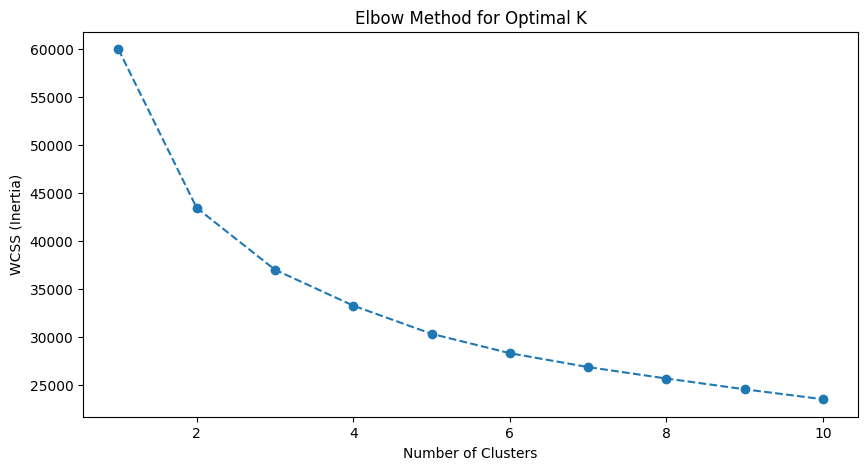

In [61]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 3. Use the Elbow Method to justify the number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')

# Export the plot
plt.savefig(os.path.join(report_path, "elbow_method_for_optimal_k"), dpi=300, bbox_inches='tight')
print(f"Plot exported to: {report_path}")

plt.show()

# Based on the plot, we will choose K=3 where the "elbow" is most prominent.

## Algorithm 1 - K-Means Clustering

In [62]:
from sklearn.cluster import KMeans

# Initialize and fit K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
data['kmeans_label'] = kmeans.fit_predict(X_scaled)

print("K-Means clustering complete.")

K-Means clustering complete.


## Algorithm 2 - Gaussian Mixture Model (GMM)

In [63]:
from sklearn.mixture import GaussianMixture

# Initialize and fit GMM
gmm = GaussianMixture(n_components=3, random_state=42)
data['gmm_label'] = gmm.fit_predict(X_scaled)

print("GMM clustering complete.")

GMM clustering complete.


## PCA Visualization

Plot exported to: ../reports/Task3


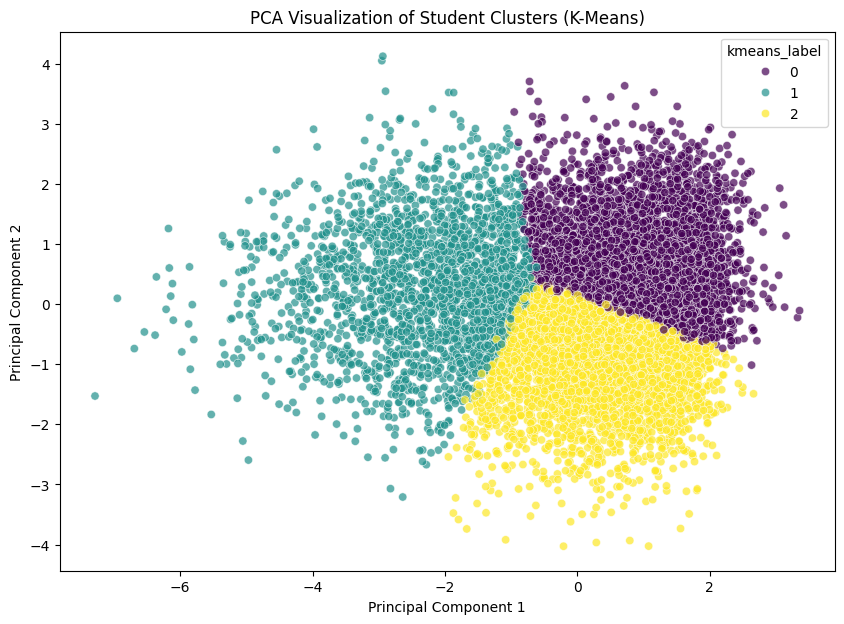

In [64]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# 4. Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
data['pca1'] = pca_data[:, 0]
data['pca2'] = pca_data[:, 1]

# Plot the result
plt.figure(figsize=(10, 7))
sns.scatterplot(data=data, x='pca1', y='pca2', hue='kmeans_label', palette='viridis', alpha=0.7)
plt.title('PCA Visualization of Student Clusters (K-Means)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Export the plot
plt.savefig(os.path.join(report_path, "pca_clusters_visualization_k_means"), dpi=300, bbox_inches='tight')
print(f"Plot exported to: {report_path}")

plt.show()

## Cluster Statistical Analysis and Labeling

In [65]:
# Describe each cluster in plain language
cluster_analysis = data.groupby('kmeans_label')[cluster_features].mean()
print(cluster_analysis)

                   GPA  study_hours_per_day  mental_stress_level  \
kmeans_label                                                       
0             0.583168             0.276055            -0.713475   
1            -1.346721            -1.147181             0.251988   
2             0.214611             0.425174             0.623497   

              final_exam_score  AI_tool_usage_hours  sleep_hours  
kmeans_label                                                      
0                    99.025386             0.042039     0.680136  
1                    86.257856             0.018595    -0.195791  
2                    99.010385            -0.057970    -0.622565  


Cluster 0 (Purple) - High GPA (0.58), highest sleep hours (0.68), and very low mental stress (-0.71). These students perform well (Score: 99.03) while maintaining wellness.

Cluster 1 (Teal) - Lowest GPA (-1.35) and lowest exam scores (86.26). They have significantly lower study hours and slightly elevated stress compared to Cluster 0.

Cluster 2 (Yellow) - High GPA (0.21) and high exam scores (99.01), but at a cost: they have the highest mental stress (0.62) and the lowest sleep hours (-0.62).

## Interpretation and Output

In [66]:
# Save to data/clustered.csv

# We use the K-Means label as our data for the next task
data['cluster_label'] = data['kmeans_label']
data.to_csv(os.path.join(cfg['paths']['data_dir'], 'clustered.csv'), index=False)

print("Clustered data saved to data/clustered.csv")

Clustered data saved to data/clustered.csv


## Interpretation of Segmentation

The unsupervised segmentation reveals a complex relationship between academic performance and mental well-being. The separation in the PCA plot is notably clean between the Teal cluster (struggling students) and the high-performing groups, suggesting that academic output is a primary differentiator. However, the most insightful finding is the split between the Purple and Yellow clusters.

Both groups achieve nearly identical exam scores (approximately 99), yet their lifestyle profiles are diametrically opposed. Cluster 0 represents a "healthy" success model with high sleep and low stress. In contrast, Cluster 2 represents a "sacrifice" model, achieving high marks through intense study hours, minimal sleep, and high stress levels. This indicates that academic achievement alone is not a sufficient metric for student health. The separation between these two high-performing groups is somewhat ambiguous in the center of the PCA plot, suggesting a "tipping point" where balanced habits degrade into over-exertion. This segmentation is highly valuable for Task 4, as it provides a behavioral feature that standard regression might overlook.